In [ ]:
## 2026.06.13 using SeededNTM env
##            Copy from Xenium_lung/Data_process_visual_xenium_4.ipynb
##            See the HE image
## 2026.06.18 Clean code, and then add ‘Michael_data_transfer/s4769/HE/s4769_he_mapping_updated_Visium.xlsx’
##            - 21 available, actually 38 aligned HE images, save cell type at HE/nwn-95916_aligned_d1ec33a2/figures/
##            - FinalLiv-27_c001_v001_r001_reg005_celltype_on_HE.jpg
##            - nwn-95916_aligned_d1ec33a2.tif

In [2]:
# cd /home/lingyu/ssd2/Python/Hist2Pheno
# bash code/Xenium_lung/demo_VUILD107MA.sh
# bash code/Xenium_lung/demo_VUILD102LA.sh
# bash code/Xenium_lung/demo_VUILD96LA.sh

In [3]:
## for AI edit
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

## Add the code directory to Python path
path = '/home/lingyu/ssd2/Python/'
import os
os.chdir(f'{path}Hist2Pheno/data/CODEX/HCC/')
!pwd

import sys
import pandas as pd
from pathlib import Path

_xenium_dir = Path("/home/lingyu/ssd2/Python/Hist2Pheno/code/Xenium_lung")
_codex_dir = Path("/home/lingyu/ssd2/Python/Hist2Pheno/code/CODEX_hcc")
for _d in (_xenium_dir, _codex_dir):
    if str(_d) not in sys.path:
        sys.path.insert(0, str(_d))

from plot_spatial_he_labels import plot_spatial_he_maps, DEFAULT_FIGURES_DIR
from s4769_img_cell_mapping import (
    DEFAULT_CODEX_HCC_DIR,
    S4769_SAMPLE,
    load_visium_he_mapping,
    load_codex_he_alignment,
    export_he_zarr_to_tif,
    export_aligned_he_zarrs_to_tif,
    summarize_visium_he_mapping,
    summarize_codex_he_alignment,
    load_he_rgb,
    plot_he_overview,
    load_cells_by_acq,
    summarize_acquisitions,
    plot_all_acq_spatial,
    plot_all_visium_on_he,
    load_visium_for_acq,
)

CODEX_hcc_dir = str(DEFAULT_CODEX_HCC_DIR)


/ssd2/users/lingyu/Python/Collaborate/esccAI/data


### Load HE

HE nwn-95916_aligned_d1ec33a2: shape=(3, 5431, 7236), dtype=uint8
HE RGB array: (5431, 7236, 3), value range [0, 255]
Saved: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/nwn-95916_aligned_d1ec33a2/figures/he_img_overview.jpg


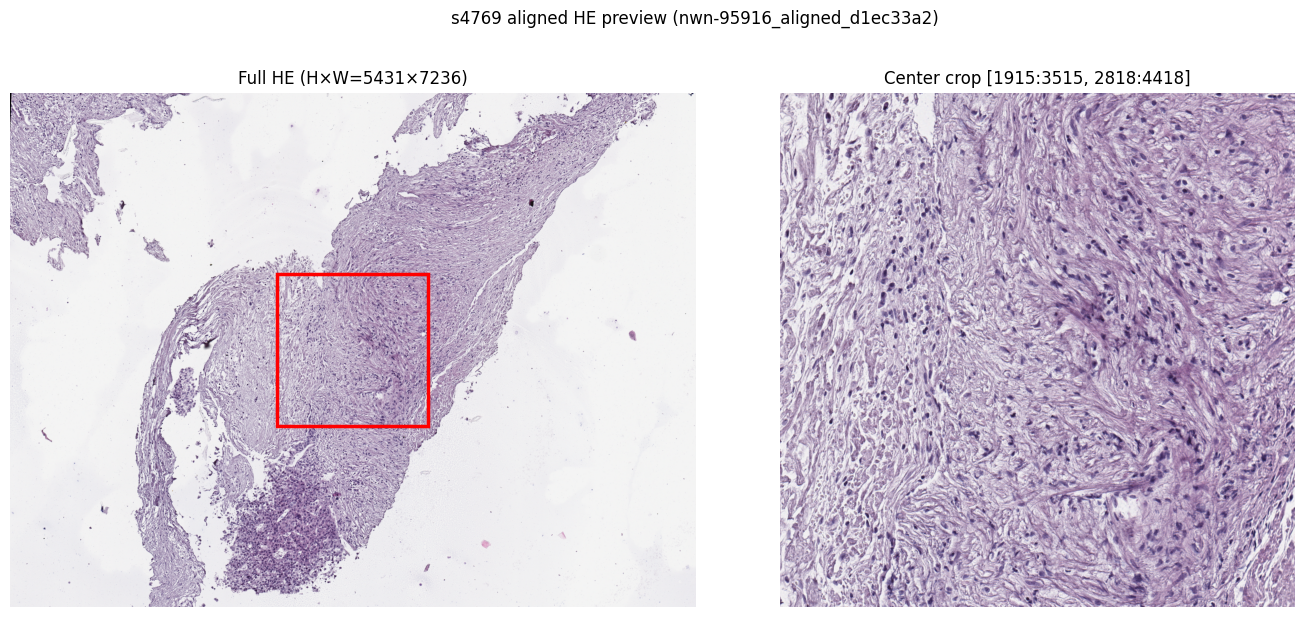

In [4]:
# reg005 aligned HE (reg006 uses nwn-95916_aligned_b16cf712)
HE_PREVIEW_KEYS = [
    'nwn-95916_aligned_d1ec33a2',   # reg005
    # 'nwn-95916_aligned_b16cf712',   # reg006
]

for he_key in HE_PREVIEW_KEYS:
    he_rgb, _ = plot_he_overview(he_key, base_dir=CODEX_hcc_dir)


### Load HE ↔ CODEX ↔ Visium mapping (Visium=Y only)


In [5]:
## Visium subset (21 rows): Visium=='Y' — required for Visium spot loading
mapping_df = load_visium_he_mapping(base_dir=CODEX_hcc_dir)
# summarize_visium_he_mapping(mapping_df, base_dir=CODEX_hcc_dir)

## CODEX↔HE alignment (38 rows): ALIGNED=='Y' — use for CODEX cell overlay on HE
alignment_df = load_codex_he_alignment(base_dir=CODEX_hcc_dir)
summarize_codex_he_alignment(alignment_df, base_dir=CODEX_hcc_dir)

## Example: load CODEX cells for selected regions
PRIMARY_ACQ_ID = 'FinalLiv-27_c001_v001_r001_reg005'
ACQ_IDS_ALSO_VIEW = []  # e.g. ['FinalLiv-27_c001_v001_r001_reg006']

cells_by_acq = load_cells_by_acq(
    PRIMARY_ACQ_ID, ACQ_IDS_ALSO_VIEW or None, base_dir=CODEX_hcc_dir,
)
cells = cells_by_acq[PRIMARY_ACQ_ID]
summarize_acquisitions(cells_by_acq, alignment_df)

## Visium spots for reg005 (mapping_df / Visium=='Y' only)
# visium_reg005 = load_visium_for_acq(PRIMARY_ACQ_ID, mapping_df, base_dir=CODEX_hcc_dir)
# print(f"\nVisium spots for {PRIMARY_ACQ_ID}: {len(visium_reg005)}")
# visium_reg005.head()


CODEX↔HE alignment rows: 38

=== FinalLiv-27_c001_v001_r001_reg001 | 70_2 ===
  MATCHED_HE='awy-98938_aligned_0d535a74'  exists=True
  Visium=False  CSV='070_2_tissue_positions_list.csv'  exists=False

=== FinalLiv-27_c001_v001_r001_reg002 | 70_3 ===
  MATCHED_HE='awy-98938_aligned_8ded610e'  exists=True
  Visium=False  CSV='070_3_tissue_positions_list.csv'  exists=False

=== FinalLiv-27_c001_v001_r001_reg003 | 70_4 ===
  MATCHED_HE='awy-98938_aligned_a5afeef9'  exists=True
  Visium=False  CSV='070_4_tissue_positions_list.csv'  exists=False

=== FinalLiv-27_c001_v001_r001_reg004 | 70_5 ===
  MATCHED_HE='awy-98938_aligned_59f27598'  exists=True
  Visium=False  CSV='070_5_tissue_positions_list.csv'  exists=False

=== FinalLiv-27_c001_v001_r001_reg005 | 71_2 ===
  MATCHED_HE='nwn-95916_aligned_d1ec33a2'  exists=True
  Visium=True  CSV='071_2_tissue_positions_list.csv'  exists=True

=== FinalLiv-27_c001_v001_r001_reg006 | 71_3 ===
  MATCHED_HE='nwn-95916_aligned_b16cf712'  exists=True
  Vi

In [ ]:
## Export ALIGNED HE Zarr → TIFF (38 datasets)
# Each HE saved as: s4769/HE/{MATCHED_HE}/figures/{MATCHED_HE}.tif
he_tif_paths = export_aligned_he_zarrs_to_tif(
    alignment_df,
    base_dir=CODEX_hcc_dir,
    skip_if_exists=True,   # set overwrite=True to re-export
)
print(f"Done: {len(he_tif_paths)} TIFF files")
he_tif_paths[:3]


In [6]:
# alignment_df
cells_by_acq

{'FinalLiv-27_c001_v001_r001_reg005':       CELL_ID  x_pix  y_pix  VALUE             celltype
 0           1   6624      4      3          Fibroblasts
 1           2    627      5     12              B cells
 2           3    130      4      7          CD4 T cells
 3           4    302      6      3          Fibroblasts
 4           5   1229      6      7          CD4 T cells
 ...       ...    ...    ...    ...                  ...
 8691     8692   1908   5383      3          Fibroblasts
 8692     8693   1810   5396      6  Macrophages M2-like
 8693     8694   2045   5415     11   Epithelium (INOS-)
 8694     8695   1759   5420      6  Macrophages M2-like
 8695     8696   1787   5421     13                INFg+
 
 [8696 rows x 5 columns]}

Saved: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/nwn-95916_aligned_d1ec33a2/figures/FinalLiv-27_c001_v001_r001_reg005_celltype_on_HE.jpg


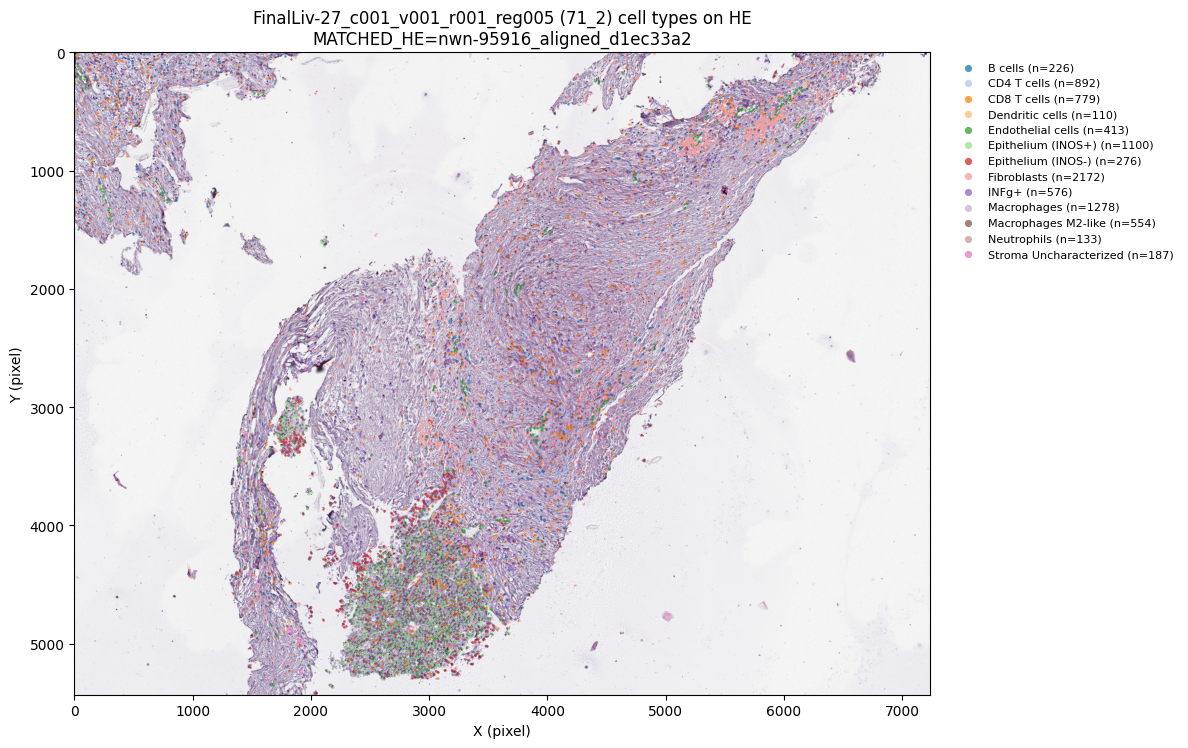

In [7]:
## CODEX cell types on MATCHED_HE (from alignment table)
plot_all_acq_spatial(cells_by_acq, alignment_df, base_dir=CODEX_hcc_dir)

## Visium tissue spots on MATCHED_HE (Visium subset only)
# plot_all_visium_on_he(
#     mapping_df, base_dir=CODEX_hcc_dir,
#     acq_ids=[PRIMARY_ACQ_ID, *(ACQ_IDS_ALSO_VIEW or [])],
# )


## Save HE image 

## Load StarDist results

In [4]:
select4_dir = f'{path}Hist2Pheno/data/Xemium/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4'
dataset_select = 'VUHD113'   # 'VUILD107MA'

import pandas as pd
def load_star_dist_data(select4_dir, dataset_select='VUHD113'):
    """Read StarDist CSV from Complete_Cases_Select4/{sample}/."""
    star_dist_path = f'{select4_dir}/{dataset_select}/{dataset_select}_Float_prob001_nms_03.csv'
    star_dist_df = pd.read_csv(star_dist_path)
    star_dist_df['sample'] = dataset_select
    print(f'[{dataset_select}] StarDist CSV: {star_dist_path}')
    print(f'[{dataset_select}] cell number of star_dist:', star_dist_df.shape)
    return star_dist_df

DATASETS = ['VUHD113', 'VUILD107MA', 'VUILD102LA', 'VUILD96LA']
star_dist_all = {
    s: load_star_dist_data(select4_dir, dataset_select=s)
    for s in DATASETS
}
star_dist_ = star_dist_all[dataset_select]

[VUHD113] StarDist CSV: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUHD113/VUHD113_Float_prob001_nms_03.csv
[VUHD113] cell number of star_dist: (23745, 4)
[VUILD107MA] StarDist CSV: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUILD107MA/VUILD107MA_Float_prob001_nms_03.csv
[VUILD107MA] cell number of star_dist: (105857, 4)
[VUILD102LA] StarDist CSV: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUILD102LA/VUILD102LA_Float_prob001_nms_03.csv
[VUILD102LA] cell number of star_dist: (60484, 4)
[VUILD96LA] StarDist CSV: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUILD96LA/VUILD96LA_Float_prob001_nms_03.csv
[VUILD96LA] cell number of star_dist: (8

In [5]:
star_dist_ = load_star_dist_data(select4_dir, dataset_select=dataset_select)
star_dist_.head()

[VUHD113] StarDist CSV: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUHD113/VUHD113_Float_prob001_nms_03.csv
[VUHD113] cell number of star_dist: (23745, 4)


,centroid_x,centroid_y,probability,sample
0,3678.293251,3560.173920,0.886976,VUHD113
1,3371.622482,3423.181580,0.883140,VUHD113
2,412.258600,795.808817,0.878218,VUHD113
3,3705.858780,3700.159309,0.874990,VUHD113
4,352.317239,705.626997,0.867907,VUHD113


### HE - StarDist

In [7]:
## Load stardist coords (Complete_Cases_Select4/{sample}/)
therapy_data = 'VUHD113'
star_coords_path = f'{select4_dir}/{therapy_data}/{therapy_data}_Float_prob001_nms_03.csv'
star_coords = pd.read_csv(star_coords_path)
print(star_coords_path)
print(star_coords.shape)
star_coords.head()

/home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUHD113/VUHD113_Float_prob001_nms_03.csv
(23745, 3)


,centroid_x,centroid_y,probability
0,3678.293251,3560.173920,0.886976
1,3371.622482,3423.181580,0.883140
2,412.258600,795.808817,0.878218
3,3705.858780,3700.159309,0.874990
4,352.317239,705.626997,0.867907
